# Developing a user engagement strategy based on analytics data for a network of fitness centers

## Contents
* [Step 1. Data Loading](#1-bullet)
* [Step 2. Exploratory Data Analysis (EDA)](#2-bullet)
* 2.1. [Feature Mining](#2-1-bullet)
* 2.2. [Mean Feature Values ​​and Graphs in Two Groups – Churners and Retainers](#2-2-bullet)
* 2.3. [Correlation Matrix](#2-3-bullet)
* [Step 3. User Churn Prediction Model](#3-bullet)
* [Step 4. User Clustering](#4-bullet)
* 4.1. [Distance Matrix Using the Linkage() Function on the Standardized Feature Matrix and Drawing the Dendrogram](#4-1-bullet)
* 4.2. [Mean Feature Values ​​for Clusters](#4-2-bullet)
* 4.3. [Feature Distributions for Clusters](#4-3-bullet)
* 4.4. [Churn Rate for Each Resulting Cluster](#4-4-bullet)
* [Step 5. Conclusion](#5-bullet)

## Step 1. Data Loading<a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

import itertools
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/sklearn/utils/fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')

In [3]:
df.head(5)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


The dataset includes user data for the month preceding the churn check:

**Gym_churn Table**
- 'gender' — Gender
- 'Near_Location' — Residence or Work in the Area Where the Fitness Center is Located
- 'Partner' — Employee of a Club Partner Company (Collaboration with Companies Whose Employees Can Receive Discounts on Memberships; in this Case, the Fitness Center Stores Information about the Client's Employer)
- Promo_friends — Initial Registration as Part of the "refer-a-friend" Promotion (Used a Promo Code from a Friend when Paying for the First Membership)
- 'Phone' — vailability of a Contact Phone Number
- 'Age' — Age
- 'Lifetime' — Time Since First Visit to the Fitness Center (in Months)
Information based on the visit log, purchases, and information about the current membership status of the client
- 'Contract_period' — Duration of the Current Membership (Month, 3 Months, etc.) 6 Months, Year)
- 'Month_to_end_contract' — Time Remaining Until the End of the Current Membership (in Months)
- 'Group_visits' — Actual Group Class Attendance
- 'Avg_class_frequency_total' — Average Weekly Visit Frequency since the Membership Began
- 'Avg_class_frequency_current_month' — Average Weekly Visit Frequency for the Previous Month
- 'Avg_additional_charges_total' — Total Revenue from Other Fitness Center Services: Cafe, Sporting Goods, Beauty and Massage Salon
- 'Churn' — Actual Churn in the Current Month

## Step 2. Exploratory Data Analysis (EDA)<a class="anchor" id="2-bullet"></a>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

- The table has 4 000 rows and 14 columns.
- There are no missing values.
- There is no need to change data types.

In [5]:
df.duplicated().sum()

0

There are no duplicates in the table

### 2.1. Feature Mining<a class="anchor" id="2-1-bullet"></a>

In [6]:
df['gender'].value_counts()

1    2041
0    1959
Name: gender, dtype: int64

**'gender'** — sex

    The data does not indicate the gender of the values ​​"0" and "1."
    For further analysis, we will define "0" as male and "1" as female.
    Therefore, 51.02% of the fitness center chain's clients are female and 48.98% are male.

In [7]:
df['Near_Location'].value_counts()

1    3381
0     619
Name: Near_Location, dtype: int64

**'Near_Location'** — residing or working in the area where the fitness center is located

    3 381 clients reside or work in the area where the fitness center is located, representing 84.53% of the total number of clients.
    And 15.47% of clients (619 people) neither live nor work in the area where the fitness center is located.

In [8]:
df['Partner'].value_counts()

0    2053
1    1947
Name: Partner, dtype: int64

**'Partner'** — an employee of a club partner company

    2 053 clients are not employees of the club's partner company (whose employees may receive discounts on memberships).
    This represents 51.33% of the total.
    1 947 clients are employees of the club's partner company, representing 48.67%.

In [9]:
df['Promo_friends'].value_counts()

0    2766
1    1234
Name: Promo_friends, dtype: int64

**Promo_friends** — initial registration as part of the "refer a friend" promotion (used a promo code from a friend when paying for their first membership)

* 2 766 customers did not use a promo code from a friend when paying for their first membership, which is 69.15%.
* 1 234 customers used a promo code as part of the "refer a friend" promotion, which is 30.85%.

In [10]:
df['Phone'].value_counts()

1    3614
0     386
Name: Phone, dtype: int64

**'Phone'** — presence of a contact phone number

* 3 614 customers provided a contact phone number (90.5%).
* 386 customers did not provide a contact phone number when making a purchase (9.65%)

In [11]:
df['Contract_period'].value_counts()

1     2207
12     960
6      833
Name: Contract_period, dtype: int64

**'Contract_period'** — the duration of the current active membership (month, 3 months, 6 months, or year)

* Most customers purchase a monthly membership – 2 207 people (55.18%)
* 960 people (24%) purchased annual memberships.
* 833 people (20.82%) purchased a 6-month membership
* No customers purchased a 3-month membership, although the data description indicates this option is available.

In [12]:
df['Group_visits'].value_counts()

0    2351
1    1649
Name: Group_visits, dtype: int64

**'Group_visits'** — fact of attending group classes

* 58.78% of clients do not attend group classes, but work out independently or with a personal trainer
* 41.22% of clients attend group classes

In [13]:
df['Age'].value_counts()

29    468
30    457
28    447
31    434
27    378
32    364
26    300
33    253
25    231
34    174
24    148
35     98
23     82
36     48
22     33
37     29
21     24
20     14
38     10
39      3
18      2
19      2
41      1
Name: Age, dtype: int64

In [14]:
df['Age'].describe()

count    4000.000000
mean       29.184250
std         3.258367
min        18.000000
25%        27.000000
50%        29.000000
75%        31.000000
max        41.000000
Name: Age, dtype: float64

**'Age' — age**

* The primary age category of clients is 27 to 32 years old (2 548 people, or 63.7%).
* Fitness centers are almost never visited by young people aged 18 to 23. Their number was 157 people, or 3.9%.
* Fitness centers are also not popular with clients over 35.
* The age category 36-41 years old - 91 people, or 2.3% of the total.
* 75% of all clients are under 31.
* The average age of all visitors is 29.

In [15]:
df['Avg_additional_charges_total'].describe()

count    4000.000000
mean      146.943728
std        96.355602
min         0.148205
25%        68.868830
50%       136.220159
75%       210.949625
max       552.590740
Name: Avg_additional_charges_total, dtype: float64

<AxesSubplot:>

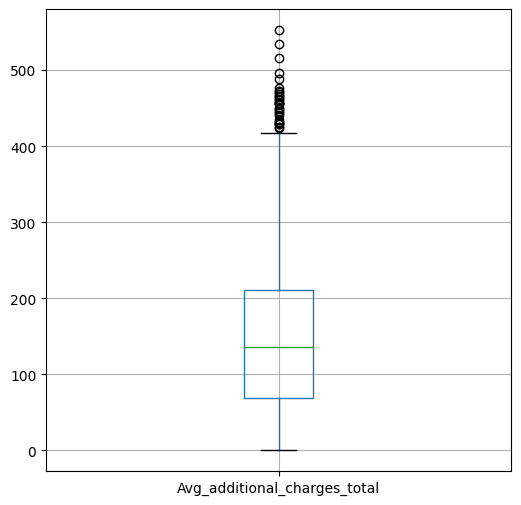

In [16]:
df.boxplot(column='Avg_additional_charges_total', figsize=(6,6))

**'Avg_additional_charges_total'** — total revenue from other fitness center services:
cafe, sporting goods, beauty and massage salon

* minimum receipt for additional services - 0.15 dollars
* 25% of receipts for additional services do not exceed 68.87 dollars
* average receipt for additional services - 146.94 dollars
* median - $136.22. The median is less than the mean, meaning the data is skewed to the right
* 75% of receipts for additional services do not exceed 210.95 dollars
* 90% of receipts for additional services do not exceed 410 dollars
* Outliers start at 410 dollars up to 552.59 USD. The biggest outlier is a receipt for 552.59 USD.

In [17]:
df['Month_to_end_contract'].value_counts()

1.0     2207
6.0      645
12.0     524
11.0     181
5.0      130
10.0      82
9.0       73
4.0       58
8.0       38
7.0       25
3.0       23
2.0       14
Name: Month_to_end_contract, dtype: int64

**'Month_to_end_contract'** — the remaining time of the current subscription (in months)
* 2 207 people purchased monthly subscriptions, meaning that 2 207 people's subscriptions expire in 1 month (55.18%).
* 19.38% of customers will have their subscriptions expire in 5-6 months.
* 17.63% of customers will have their subscriptions expire in 11-12 months.
* These three main groups make up 92.19% of the total number of customers in the dataset.

In [18]:
df['Avg_class_frequency_total'].describe()

count    4000.000000
mean        1.879020
std         0.972245
min         0.000000
25%         1.180875
50%         1.832768
75%         2.536078
max         6.023668
Name: Avg_class_frequency_total, dtype: float64

<AxesSubplot:>

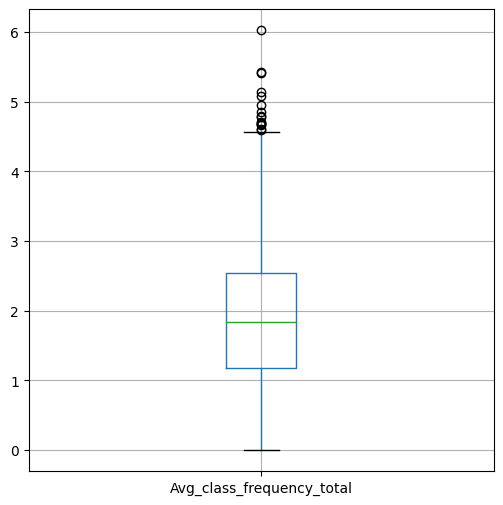

In [19]:
df.boxplot(column='Avg_class_frequency_total', figsize=(6,6))

In [20]:
df[df['Avg_class_frequency_total'] == 0]['Avg_class_frequency_total'].count()

88

**'Avg_class_frequency_total'** — средняя частота посещений в неделю за все время с начала действия абонемента
    
    *  минимальное количество посещений в неделю - 0 раз. 88 человек еще не посетили фитнес-центр, это 2,2%
    *  25% человек в среднем посещают клуб 1.18 раз в неделю
    *  среднее значение посещений в недею - 1.88 раз
    *  медиана - 1.83 раз. Медиана меньше среднего значения, значит данные скошены в правую сторону
    *  75% человек в среднем посещают клуб 2.54 раз в неделю
    *  90% человек в среднем посещают клуб не более 4.5 раз в неделю
    *  Выбросы начинаются от 4,5 до 6 раз в неделю. Самый большой выброс - 6 раз в неделю.

In [21]:
df['Avg_class_frequency_current_month'].describe() 

count    4000.000000
mean        1.767052
std         1.052906
min         0.000000
25%         0.963003
50%         1.719574
75%         2.510336
max         6.146783
Name: Avg_class_frequency_current_month, dtype: float64

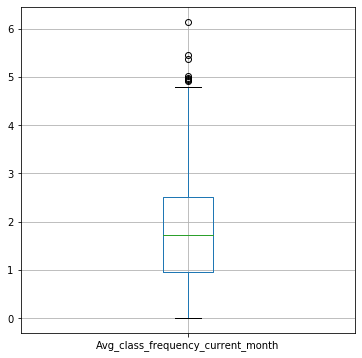

In [22]:
df.boxplot(column='Avg_class_frequency_current_month', figsize=(6,6))

In [20]:
df[df['Avg_class_frequency_current_month'] == 0]['Avg_class_frequency_current_month'].count()

181

**'Avg_class_frequency_current_month'** — Average weekly visit frequency for the previous month

* Minimum weekly visit frequency is 0. 181 people have not yet visited the fitness center, or 2.2%.
* 25% of people visited the club an average of 0.96 times per week over the past month.
* Average weekly visit frequency for the past month is 1.77 times.
* Median is 1.72 times. The median is lower than the mean, meaning the data is skewed to the right.
* 75% of people visit the club an average of 2.51 times per week.
* 90% of people visited the club an average of 4.9 times per week or less in the past month.
* Outliers range from 4.9 to 6.15 times per week. The largest outlier is 6.15 times per week.

In [21]:
df['Lifetime'].describe()

count    4000.000000
mean        3.724750
std         3.749267
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        31.000000
Name: Lifetime, dtype: float64

In [22]:
df[df['Lifetime'] == 0]['Lifetime'].count()

487

<AxesSubplot:>

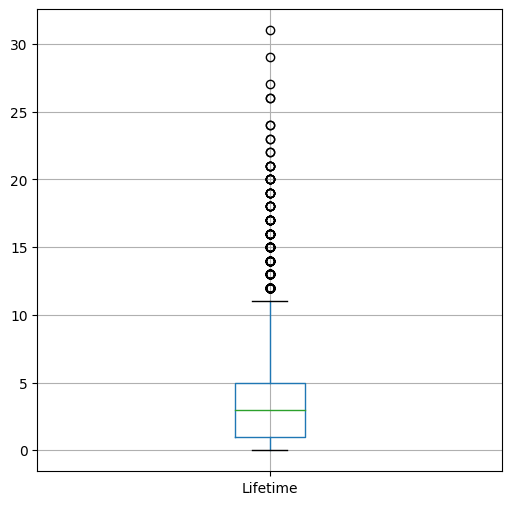

In [23]:
df.boxplot(column='Lifetime', figsize=(6,6))

***'Lifetime'*** — time since first contact with the fitness center (in months)

* 487 clients have not yet been a month since their first contact, representing 12.18% of the total.
* 25% are within one month of their first contact.
* Average: 3.7 months since their first contact.
* Median: 3 months. The median is less than the average, meaning the data is skewed to the right.
* 75% are within five months of their first contact.
* 90% are within eleven months of their first contact.
* Outliers begin between 12 and 31 months. The largest outlier is 31 months.

In [24]:
df['Churn'].value_counts()

0    2939
1    1061
Name: Churn, dtype: int64

**'Churn'** — actual churn for the current month

* 1 061 customers stopped visiting the fitness center, representing 26.53%
* 2 939 customers continue to visit the fitness center, representing 73.47% of the total

### 2.2. Mean Feature Values ​​and Graphs in Two Groups – Churners and Retainers <a class="anchor" id="2-2-bullet"></a>

In [25]:
df.groupby(['Churn', 'gender']).agg({'gender':'count'})

gender
Churn gender        
0     0         1440
      1         1499
1     0          519
      1          542

Text(0.5, 0, 'Remained                  Left')

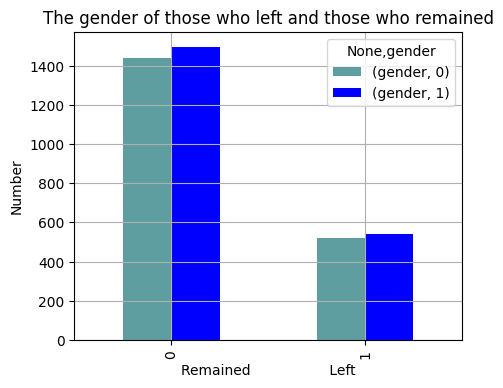

In [26]:
df.pivot_table(index='Churn', columns='gender', aggfunc=({'gender':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'),  figsize=(5, 4))
plt.title('The gender of those who left and those who remained')
plt.ylabel('Number')
plt.xlabel('Remained                  Left')

#### gender

*Group of customers who continued to visit:*
- 49% men
- 51% women

*Group of customers who stopped visiting:*
- 48.92% men
- 51.08% women

We can assume that gender is not a significant factor in determining the likelihood of churn

In [27]:
df.groupby(['Churn', 'Near_Location']).agg({'Near_Location':'count'})

Near_Location
Churn Near_Location               
0     0                        373
      1                       2566
1     0                        246
      1                        815

Text(0.5, 0, 'Remained                  Left')

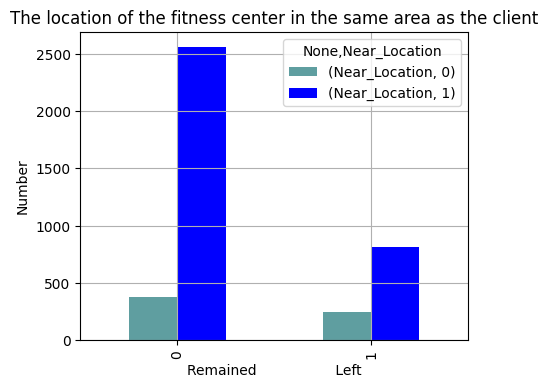

In [28]:
df.pivot_table(index='Churn', columns='Near_Location', aggfunc=({'Near_Location':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'),  figsize=(5, 4))
plt.title('The location of the fitness center in the same area as the client')
plt.ylabel('Number')
plt.xlabel('Remained                  Left')

#### Near_Location

*Group of clients who continued attending:*
- 87.3% lived or worked in the same area as the club
- 12.69% of clients lived or worked in a different area.

The opposite situation applies to the *group of clients who stopped attending*:
- 76.81% lived or worked in a different area
- 23.19% lived or worked in the same area as the club

We can assume that the distance of the club from where they live or work is an important factor.

In [29]:
df.groupby(['Churn', 'Partner']).agg({'Partner':'count'})

Partner
Churn Partner         
0     0           1369
      1           1570
1     0            684
      1            377

Text(0.5, 0, 'Remained                  Left')

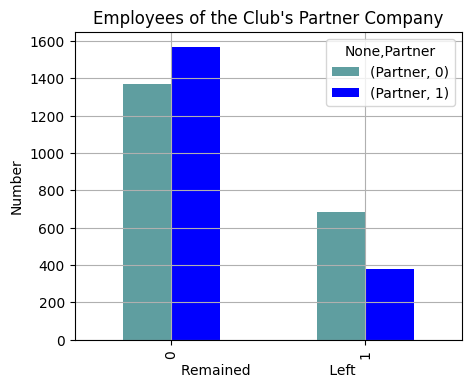

In [32]:
df.pivot_table(index='Churn', columns='Partner', aggfunc=({'Partner':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(5, 4))
plt.title('''Employees of the Club's Partner Company''')
plt.ylabel('Number')
plt.xlabel('Remained                  Left')

#### Partner

*Group of customers who continued visiting:*
- 53.42% are employees of a club partner company and received a discount on memberships
- 46.58% are not employees of a club partner company

*Group of customers who stopped visiting:*
- 35.53% are employees of a club partner company and received a discount on memberships
- 64.47% are not employees of a club partner company

We can assume that the availability of a discount on memberships from employees of a club partner company is significant when predicting potential customer churn

In [33]:
df.groupby(['Churn', 'Promo_friends']).agg({'Promo_friends':'count'})

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Promo_friends
Churn Promo_friends               
0     0                       1900
      1                       1039
1     0                        866
      1                        195

Text(0.5, 0, 'Remained                  Left')

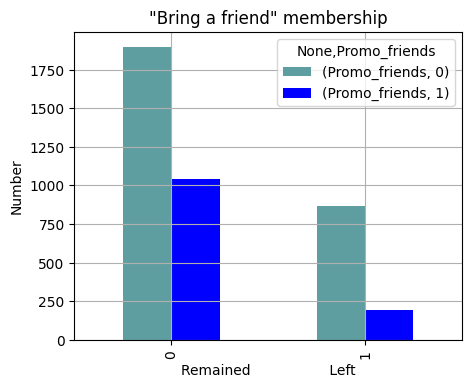

In [34]:
df.pivot_table(index='Churn', columns='Promo_friends', aggfunc=({'Promo_friends':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(5, 4))
plt.title('"Bring a friend" membership')
plt.ylabel('Number')
plt.xlabel('Remained                  Left')

#### Promo_friends

*Group of continuing visitors:*
- 64.65% of customers did not receive a discount on their first membership through the "refer a friend" promotion
- 35.35% of customers received a discount on their first membership through the "refer a friend" promotion

*Group of customers who stopped visiting*:
- 81.62% of customers did not receive a discount on their first membership through the "refer a friend" promotion
- 18.38% of customers received a discount on their first membership through the "refer a friend" promotion

We can assume that the availability of a discount on the first membership through the "refer a friend" promotion is important when predicting potential customer churn.

In [35]:
df.groupby(['Churn', 'Phone']).agg({'Phone':'count'})

Phone
Churn Phone       
0     0        283
      1       2656
1     0        103
      1        958

Text(0.5, 0, 'Remained                  Left')

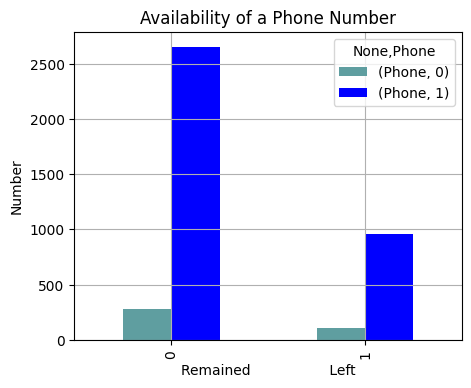

In [36]:
df.pivot_table(index='Churn', columns='Phone', aggfunc=({'Phone':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(5, 4))
plt.title('Availability of a Phone Number')
plt.ylabel('Number')
plt.xlabel('Remained                  Left')

#### Phone

*Group of customers who continued to visit:*
- 90.37% of customers provided a phone number
- 9.3% of customers did not have a phone number

*Group of customers who abandoned their visit:*
- 90.29% of customers provided a phone number
- 9.71% of customers did not have a phone number

We can assume that the presence or absence of a customer's phone number is not a significant factor in determining the likelihood of churn.

In [37]:
df.groupby(['Churn', 'Group_visits']).agg({'Group_visits':'count'})

Group_visits
Churn Group_visits              
0     0                     1575
      1                     1364
1     0                      776
      1                      285

Text(0.5, 0, 'Remained                  Left')

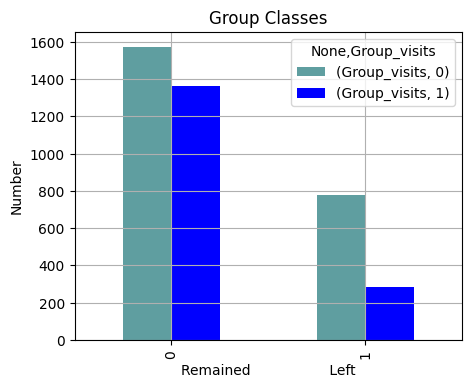

In [38]:
df.pivot_table(index='Churn', columns='Group_visits', aggfunc=({'Group_visits':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(5, 4))
plt.title('Group Classes')
plt.ylabel('Number')
plt.xlabel('Remained                  Left')

#### Group_visits

*Group of continuing attendees:*
- 53.59% of clients do not attend group classes
- 46.41% of clients attend group classes

*Group of clients who stopped attending:*
- 73.14% of clients did not attend group classes
- 26.86% of clients attended group classes

We can assume that attendance at group classes is important in predicting potential client churn

In [39]:
df.groupby(['Churn']).agg({'Age':'mean', 'Lifetime':'mean', 'Contract_period':'mean', 'Month_to_end_contract':'mean', 'Avg_class_frequency_total':'mean', 'Avg_class_frequency_current_month':'mean', 'Avg_additional_charges_total':'mean'})

,Age,Lifetime,Contract_period,Month_to_end_contract,Avg_class_frequency_total,Avg_class_frequency_current_month,Avg_additional_charges_total
Churn,,,,,,,
0,29.976523,4.711807,5.747193,5.283089,2.024876,2.027882,158.445715
1,26.989632,0.990575,1.728558,1.662582,1.474995,1.044546,115.082899


*Age*
- Average age in the group of continuing members - 29.98
- Average age in the group of discontinued members - 26.99
- Conclusion: It is mainly the "younger category" of clients who are leaving

*Time since first visit to the fitness center (in months)*
- Average Lifetime in the group of continuing members - 4.7
- Average Lifetime in the group of discontinued members - 0.99
- Conclusion: It is mainly new clients who are leaving

*Duration of the current active membership*
- Average membership duration in the group of continuing members - 5.75
- Average membership duration in the group of discontinued members - 1.73
- Conclusion: It is mainly short-term members who are leaving

*Time remaining on the current active membership (in months)*
- Average time remaining on the membership in the group of continuing members - 5.28
- Average time remaining on the membership Membership frequency in the discontinued group: 1.66
- Conclusion: Clients who are about to renew their membership are leaving.

*Average weekly visit frequency since the membership began*
- Average in the continuing group: 2.02
- Average in the discontinued group: 1.47
- Conclusion: Clients who discontinued their visits visited the club less frequently.

*Average weekly visit frequency for the previous month*
- Average in the continuing group: 2.03
- Average in the discontinued group: 1.04
- Conclusion: Clients who discontinued their visits visited the club less frequently in the last month.

*Total revenue from other fitness center services*
- Average in the continuing group: 158.45 USD
- Average in the discontinued group: 115.08 USD - Conclusion: customers who stopped visiting spent less on additional services

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 0, 'Age')

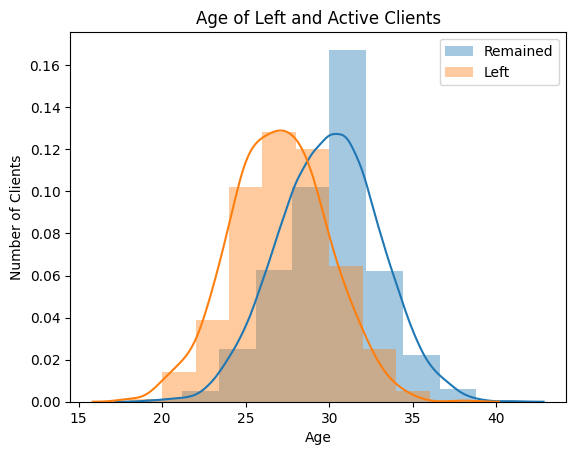

In [40]:
sns.distplot(df[df['Churn']==0]['Age'], bins=10, label='Remained')
sns.distplot(df[df['Churn']==1]['Age'], bins=10, label='Left')
plt.legend()
plt.title('Age of Left and Active Clients')
plt.ylabel('Number of Clients')
plt.xlabel('Age')

    We see that the age distribution graph of customers who churn is shifted to the left relative to the graph of customers who continue to visit the club.
    The majority of customers who churn are 27-29 years old.
    The majority of customers who continue to visit are 30-33 years old.

Text(0.5, 0, 'Number of Months Lifetime')

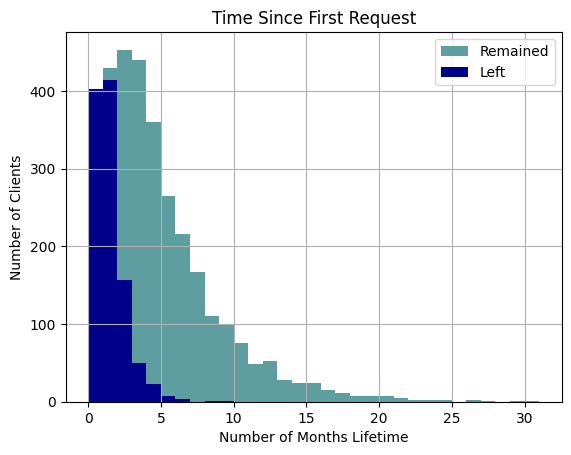

In [41]:
ax = df[df['Churn']==0]['Lifetime'].hist(bins=31, color = 'cadetblue', range=(0,31), label = 'Remained')
df[df['Churn']==1]['Lifetime'].hist(ax=ax, bins=31, color = 'darkblue', range=(0,31), label = 'Left')
plt.legend()
plt.title('Time Since First Request')
plt.ylabel('Number of Clients')
plt.xlabel('Number of Months Lifetime')

#### Lifetime

*churn group*:
- 1-2 months have passed since first visiting the fitness center

*continuing group*:
- more than 6 months have passed since first visiting the fitness center

Text(0.5, 0, 'Number of Months in the Subscription')

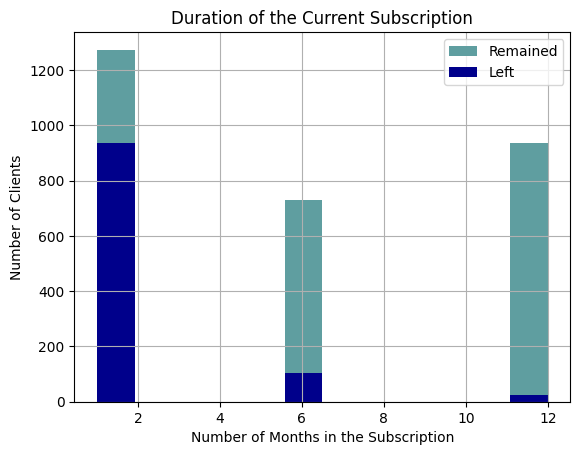

In [42]:
ax = df[df['Churn']==0]['Contract_period'].hist(bins=12, color = 'cadetblue', range=(1,12), label = 'Remained')
df[df['Churn']==1]['Contract_period'].hist(ax=ax, bins=12, color = 'darkblue', range=(1,12), label = 'Left')
plt.legend()
plt.title('Duration of the Current Subscription')
plt.ylabel('Number of Clients')
plt.xlabel('Number of Months in the Subscription')

#### Contract_period

*group that lost membership*:
- mostly purchase 1-month passes

*group that continues to attend*:
- also purchase 6- and 12-month passes

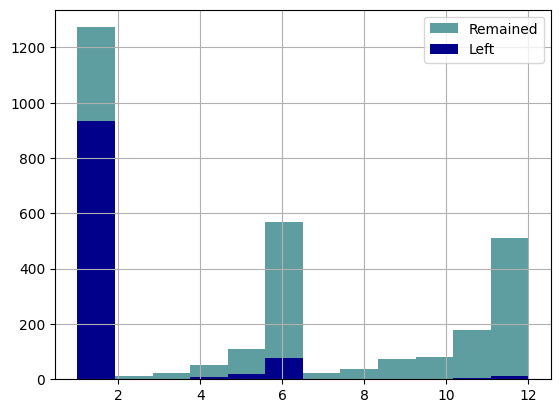

In [43]:
ax = df[df['Churn']==0]['Month_to_end_contract'].hist(bins=12, color = 'cadetblue', range=(1,12), label = 'Remained')
df[df['Churn']==1]['Month_to_end_contract'].hist(ax=ax, bins=12, color = 'darkblue', range=(1,12), label = 'Left')
plt.legend()

#### Month_to_end_contract

*group that has churn*:
- membership will expire in a month

*group that continues to attend*:
- memberships also expire in 5-6 and 10-12 months

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 0, 'Average Frequency of Visits per Week')

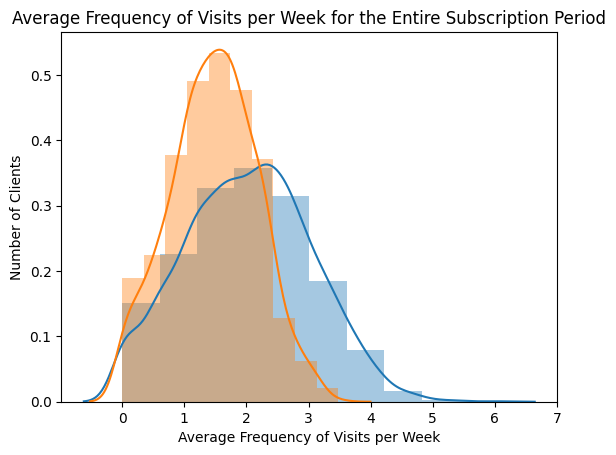

In [44]:
sns.distplot(df[df['Churn']==0]['Avg_class_frequency_total'], bins=10, label='0')
sns.distplot(df[df['Churn']==1]['Avg_class_frequency_total'], bins=10, label='1')
plt.title('Average Frequency of Visits per Week for the Entire Subscription Period')
plt.ylabel('Number of Clients')
plt.xlabel('Average Frequency of Visits per Week')

#### Avg_class_frequency_total

*churn group*:
- the graph is shifted to the left, relative to the group that continues to visit. Most clients visit 1-2 times a week, and no more than 3-4 times.

*continuing group*:
- Clients mostly visit the club 2-3 times. Some clients visit 3-4 times a week.

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 0, 'Average Frequency of Visits')

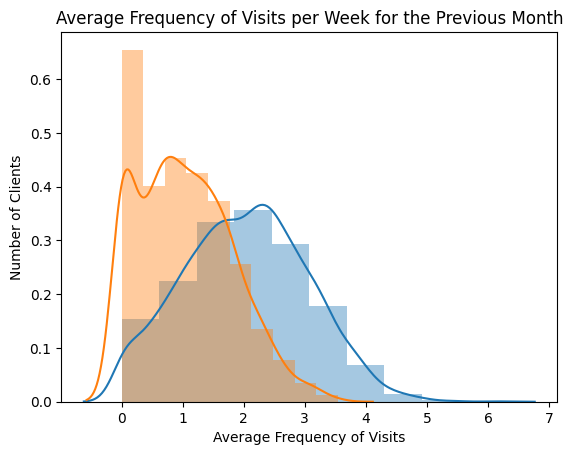

In [45]:
sns.distplot(df[df['Churn']==0]['Avg_class_frequency_current_month'], bins=10, label='0')
sns.distplot(df[df['Churn']==1]['Avg_class_frequency_current_month'], bins=10, label='1')
plt.title('Average Frequency of Visits per Week for the Previous Month')
plt.ylabel('Number of Clients')
plt.xlabel('Average Frequency of Visits')

#### Avg_class_frequency_current_month

*churn group*:
- over the previous month, most clients either did not visit the club or visited once a week.

*continuing group*:
- over the previous month, most clients visited the club 2-3 times.

/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/envs/practicum/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 0, 'Revenue')

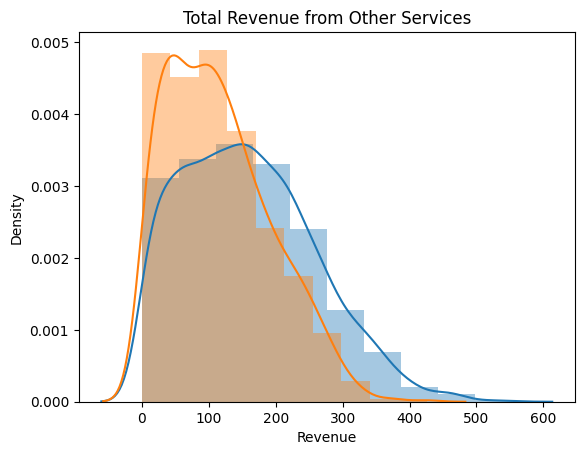

In [46]:
sns.distplot(df[df['Churn']==0]['Avg_additional_charges_total'], bins=10, label='0')
sns.distplot(df[df['Churn']==1]['Avg_additional_charges_total'], bins=10, label='1')
plt.title('Total Revenue from Other Services')
plt.xlabel('Revenue')

#### Avg_additional_charges_total

*churn group*:
- total revenue for additional services from 0 to 150 units. The graph is located to the left of customers who continue to visit.

*continuing group*:
- total revenue for additional services from 0 to 210 units.

### 2.3. Correlation Matrix<a class="anchor" id="2-3-bullet"></a> 

In [47]:
# correlation matrix
corr_m = df.corr().round(2)

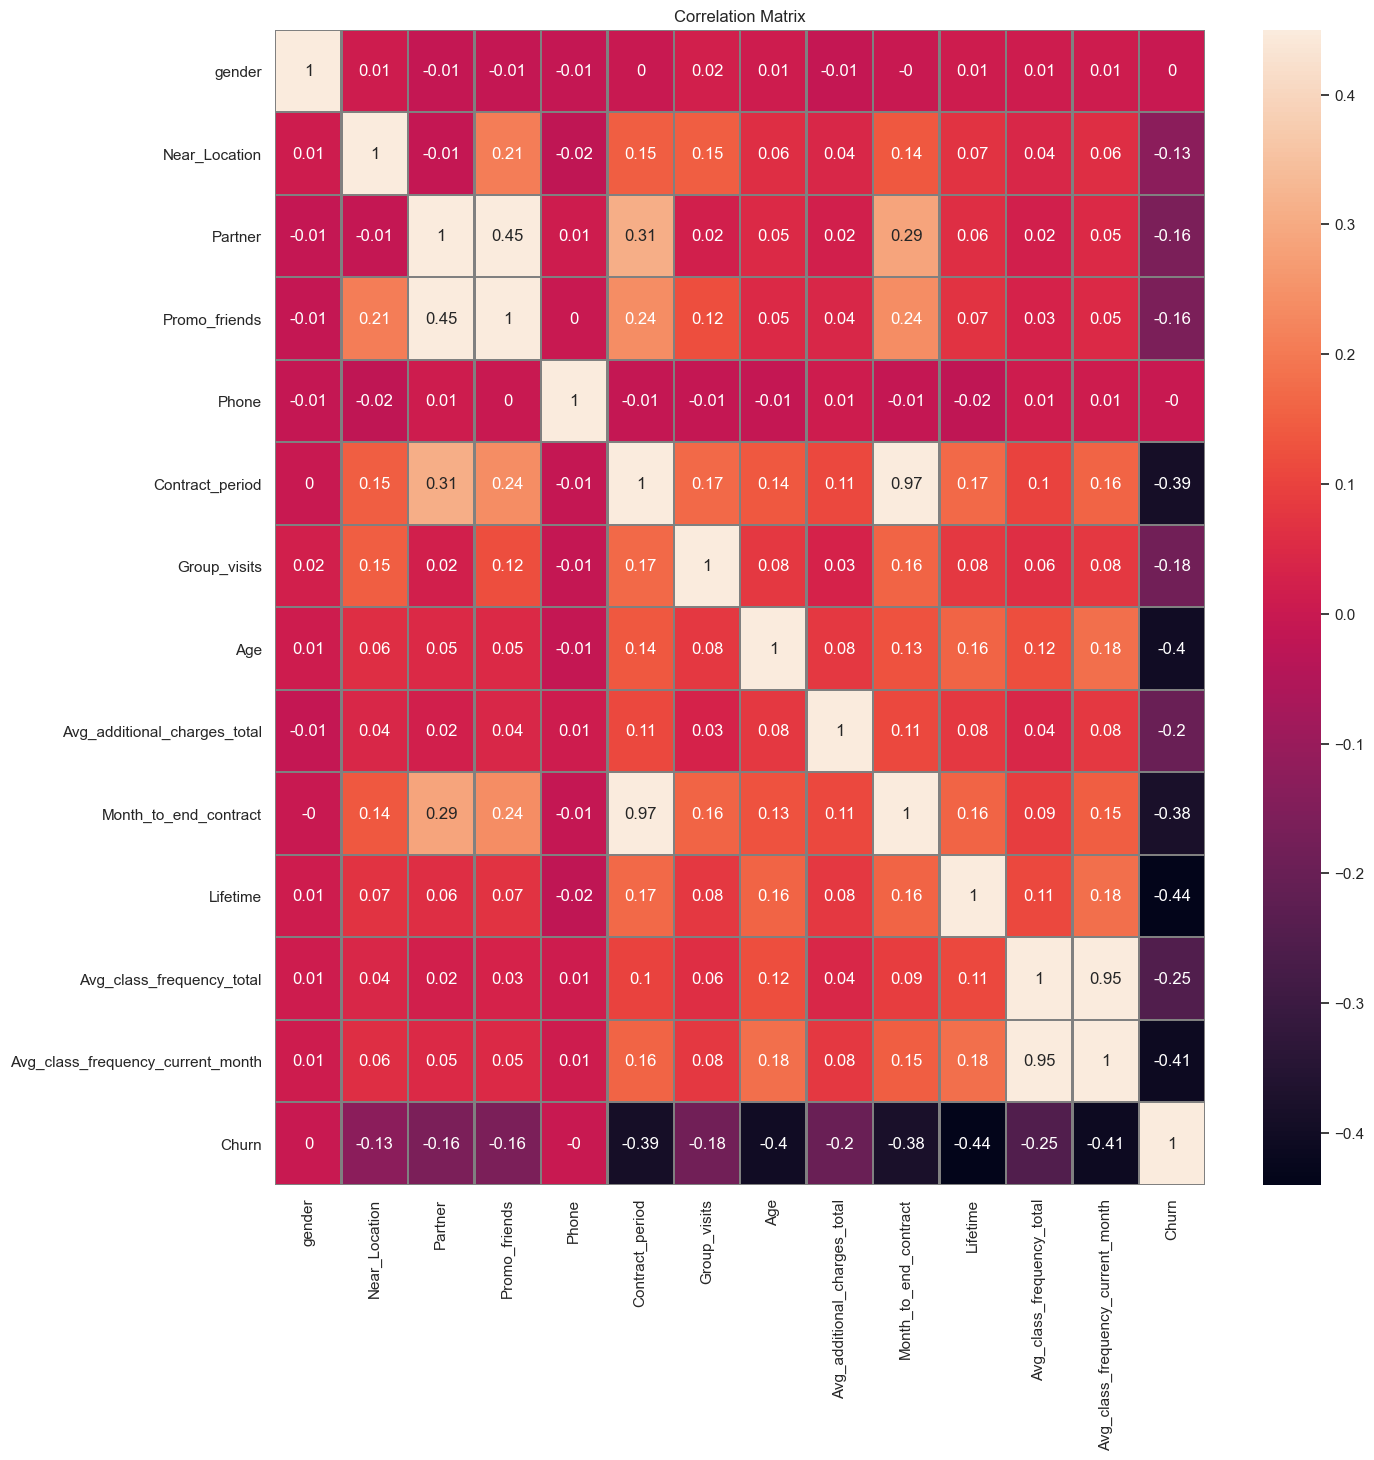

In [48]:
# heatmap
sns.set(style='white')
plt.figure(figsize=(15, 15))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr_m, annot=True, linewidths=1, linecolor='gray', vmax=0.45)

    Judging by the correlation matrix, there are no features that provide the correct answer with a high probability.
    However, there are two pairs of correlated features: "Contract_period" and "Month_to_end_contract,"
    as well as "Avg_class_frequency_total" and "Avg_class_frequency_current_month."

## Step 3. User Churn Prediction Model<a class="anchor" id="3-bullet"></a>

In [50]:
# Let's define a function that will output our metrics.
def print_all_metrics(y_true, y_pred, y_proba, title = 'Classification Metrics'):
    print(title)
    print('\tAccuracy: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print('\tPrecision: {:.2f}'.format(precision_score(y_true, y_pred)))
    print('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))
    print('\tF1: {:.2f}'.format(f1_score(y_true, y_pred)))
    print('\tROC_AUC: {:.2f}'.format(roc_auc_score(y_true, y_proba)))

In [51]:
# Let's split our data into features (matrix X) and the target variable (y)
X = df.drop(columns = ['Churn'])
y = df['Churn']

In [52]:
# We split the model into a training and validation set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [53]:
# Train StandardScaler on the training set
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [54]:
# Transform training and validation datasets
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [55]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [56]:
# Let's define an algorithm for the logistic regression model
lr_model = LogisticRegression(random_state=0)
# Let's train the model
lr_model.fit(X_train_st, y_train)
# Let's use an already trained model to make predictions.
lr_predictions = lr_model.predict(X_test_st)
lr_probabilities = lr_model.predict_proba(X_test_st)[:,1]
# Let's show all the metrics
print_all_metrics(y_test, lr_predictions, lr_probabilities , title='Metrics for the Logistic Regression Model:')

Metrics for the Logistic Regression Model:
	Accuracy: 0.92
	Precision: 0.85
	Recall: 0.83
	F1: 0.84
	ROC_AUC: 0.97


In [57]:
# We will define an algorithm for a new model based on the random forest algorithm
rf_model = RandomForestClassifier(n_estimators = 100, random_state=0)
# обучим модель случайного леса
rf_model.fit(X_train_st, y_train)

# Let's use an already trained model to make predictions.
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1] 
# Let's show all the metrics
print_all_metrics(y_test, rf_predictions, rf_probabilities, title = 'Metrics for the Random Forest Model:')

Metrics for the Random Forest Model:
	Accuracy: 0.92
	Precision: 0.84
	Recall: 0.81
	F1: 0.83
	ROC_AUC: 0.97


In [58]:
# Let's do the same for the gradient boosting algorithm
gb_model = GradientBoostingClassifier(n_estimators = 100, random_state=0)
gb_model.fit(X_train_st, y_train)
gb_predictions = gb_model.predict(X_test_st)
gb_probabilities = gb_model.predict_proba(X_test_st)[:,1]
# Let's show all the metrics
print_all_metrics(y_test, gb_predictions, gb_probabilities, title = 'Metrics for the Gradient Boosting Model:')

Metrics for the Gradient Boosting Model:
	Accuracy: 0.93
	Precision: 0.88
	Recall: 0.84
	F1: 0.86
	ROC_AUC: 0.98


Binary user classification models were built, where the target feature was the fact of user churn in the following month: LogisticRegression(), RandomForestClassifier(), GradientBoostingClassifier()

Based on the metrics, the GradientBoostingClassifier() model performed best across all metrics:
* Accuracy: 0.93
* Precision: 0.88
* Recall: 0.84
* F1: 0.86
* ROC_AUC: 0.98

## Step 4. User Clustering<a class="anchor" id="4-bullet"></a>

### 4.1.  Distance Matrix Using the Linkage() Function on the Standardized Feature Matrix and Drawing the Dendrogram<a class="anchor" id="4-1-bullet"></a>

Let's agree to take n=5 as the number of clusters.

In [59]:
X = df.drop('Churn', axis = 1)

In [59]:
# standardization of data before working with algorithms
sc = StandardScaler()
X_sc = sc.fit_transform(X)

km = KMeans(n_clusters = 5, random_state=0) # we set the number of clusters equal to 5
labels = km.fit_predict(X_sc) # we apply the algorithm to the data and form a vector of clusters

In [60]:
# Let's draw a dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

In [61]:
linked = linkage(X_sc, method = 'ward')

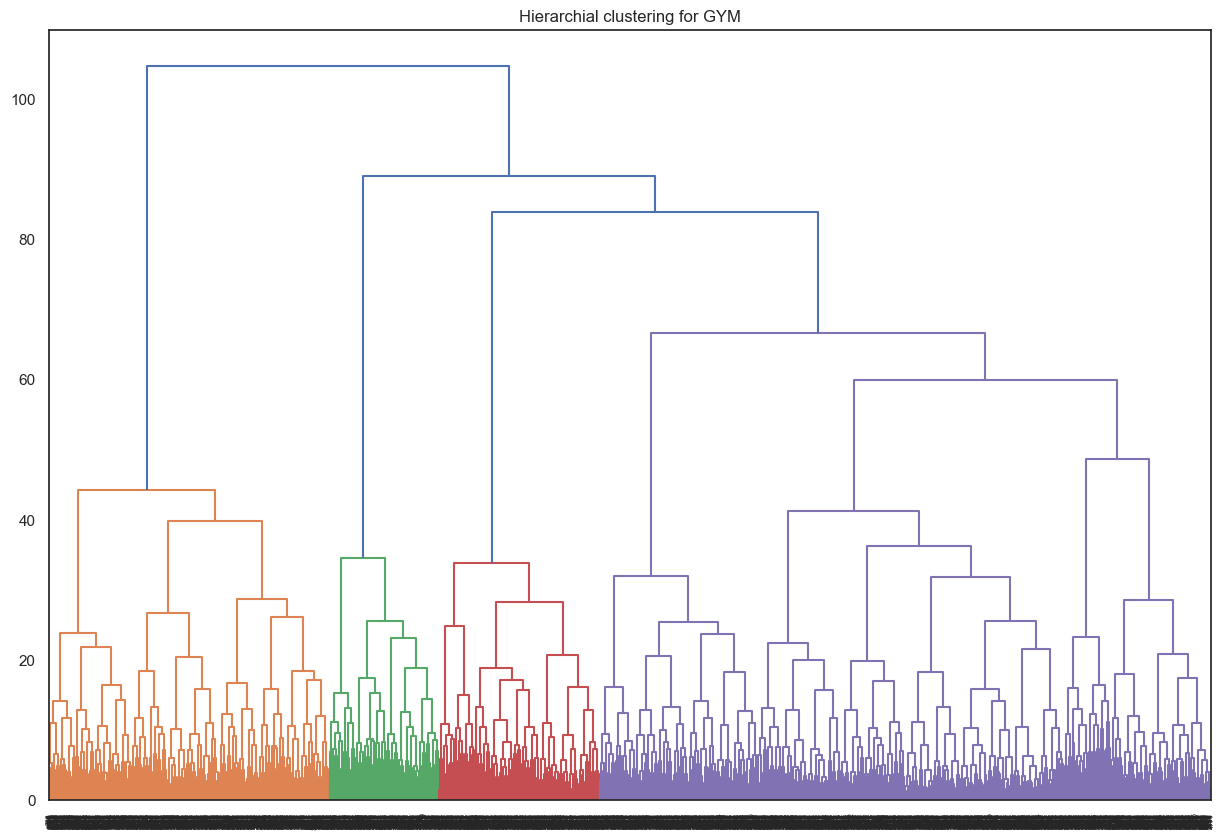

In [62]:
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Hierarchial clustering for GYM')
plt.show()

***Judging by the diagram, there are only 4 clusters***

In [63]:
# Let's save the cluster labels in a field of our dataset
df['cluster_gym'] = labels

# Let's calculate the silhouette metric for our clustering
print('Silhouette_score: {:.2f}'.format(silhouette_score(X_sc, labels)))

Silhouette_score: 0.14


    The metric's value turned out to be not very high.
    The observed objects lack a clear structure and distinct divisions.

### 4.2. Mean Feature Values ​​for Clusters <a class="anchor" id="4-2-bullet"></a>

In [64]:
# we show statistics on the average values ​​of our features for the cluster
df.groupby('cluster_gym').agg('mean').round(2)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_gym,,,,,,,,,,,,,,
0,0.50,0.96,0.78,0.57,1.0,10.89,0.54,29.98,160.76,9.95,4.74,1.98,1.97,0.03
1,0.52,0.86,0.47,0.31,0.0,4.79,0.43,29.30,143.96,4.48,3.92,1.85,1.72,0.27
2,0.50,0.00,0.46,0.08,1.0,2.35,0.22,28.48,135.46,2.20,2.81,1.66,1.48,0.44
3,0.49,1.00,0.35,0.24,1.0,1.95,0.34,28.17,131.62,1.86,2.44,1.25,1.01,0.51
4,0.56,0.98,0.36,0.23,1.0,2.67,0.47,30.13,161.66,2.46,4.90,2.85,2.85,0.07


The most problematic cluster is #3, with an average Churn value of 0.51. Next comes #2, with an average Churn value of 0.44.

Let's look at the characteristics of the two problematic clusters:
* Gender - irrelevant, as clusters #3 and #2 have equal numbers of men and women – 0.49 and 0.5, respectively.
* Near_Location - in the third cluster, all clients live or work in the same area as the club, while in the second cluster, all clients live or work in a different area.
* Partner - in the third cluster, on average, 35% are employees of the club's partner company, while in the second cluster, the figure is 46%. These figures are close to those in cluster 4 (36%) and cluster 1 (47%), but customer churn there is not significant.
* Promo_friends - in cluster 3, 24% of customers took advantage of the "refer a friend" promotion. A similar figure is in cluster 4 (23%), but customer churn there is not significant. The second cluster has the lowest rate - 8%.
* Phone - All clusters include phone, except for cluster 1, where the customer churn rate is 27%.
* Contract_period - These two clusters have the shortest subscription duration, averaging 1.95 (cluster 3) and 2.35 (cluster 2).
* Group_visits - These two clusters have the lowest group lesson attendance rate, averaging 0.34 (cluster 3) and 0.22 (cluster 2).
* Age - On average, clients in these two clusters are younger than in other clusters: average age 28.17 (cluster 3) and 28.48 (cluster 2).
* Avg_additional_charges_total - On average, clients in these two clusters spent the least on additional services: 131.62 (cluster 3) and 135.46 (cluster 2).
* Month_to_end_contract - Two clusters have the fastest membership expiration dates: 1.86 (3rd cluster) and 2.20 (2nd cluster)
* Lifetime - Two clusters have the shortest time since the first visit to the fitness center (in months): 2.44 (3rd cluster) and 2.81 (2nd cluster)
* Avg_class_frequency_total - Two clusters have the lowest average weekly visit frequency since the membership began: 1.25 (3rd cluster) and 1.66 (2nd cluster)
* Avg_class_frequency_current_month - Two clusters have the lowest average weekly visit frequency for the previous month: 1.01 (3rd cluster) and 1.48 (2nd cluster)

### 4.3. Feature Distributions for Clusters<a class="anchor" id="4-3-bullet"></a>

Text(0, 0.5, 'Number')

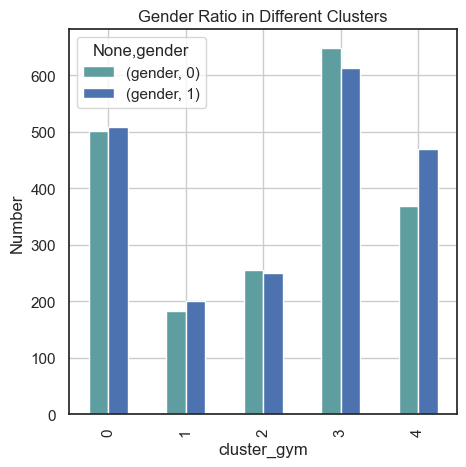

In [65]:
df.pivot_table(index='cluster_gym', columns='gender', aggfunc=({'gender':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(5, 5))
plt.title('Gender Ratio in Different Clusters')
plt.ylabel('Number')

    We see that the second and third clusters contain approximately equal numbers of women and men.
    Gender does not influence customer churn prediction.

Text(0, 0.5, 'Number')

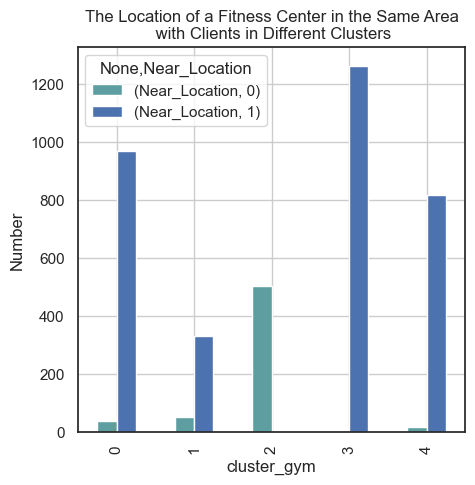

In [67]:
df.pivot_table(index='cluster_gym', columns='Near_Location', aggfunc=({'Near_Location':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(5, 5))
plt.title('The Location of a Fitness Center in the Same Area\n with Clients in Different Clusters')
plt.ylabel('Number')

    In clusters 0, 1, and 4, most clients live/work in the same area as the club.
    In cluster 2, all clients live in a different area.
    In cluster 3, all clients live in the same area.

Text(0, 0.5, 'Number')

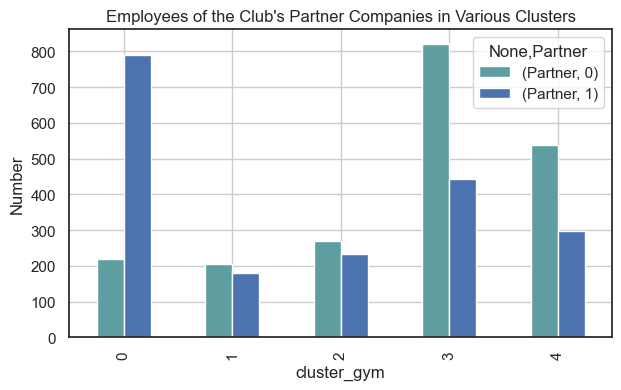

In [68]:
df.pivot_table(index='cluster_gym', columns='Partner', aggfunc=({'Partner':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(7, 4))
plt.title("Employees of the Club's Partner Companies in Various Clusters")
plt.ylabel('Number')

    The 3rd cluster with the highest customer churn has the largest number of customers who are not employees of partner companies.

Text(0, 0.5, 'Number')

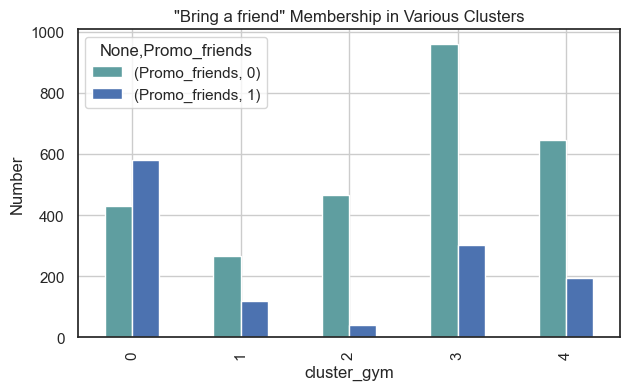

In [69]:
df.pivot_table(index='cluster_gym', columns='Promo_friends', aggfunc=({'Promo_friends':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(7, 4))
plt.title('"Bring a friend" Membership in Various Clusters')
plt.ylabel('Number')

    The third cluster has the highest rate of customers who did not use the "refer a friend" promotion.

Text(0, 0.5, 'Number')

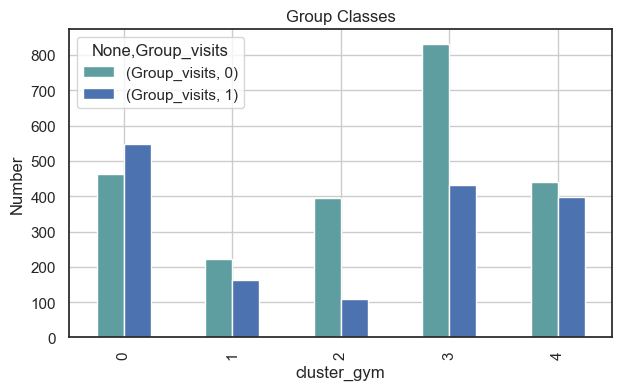

In [70]:
df.pivot_table(index='cluster_gym', columns='Group_visits', aggfunc=({'Group_visits':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(7, 4))
plt.title('Group Classes')
plt.ylabel('Number')

    The third cluster has the highest rate of clients not attending group classes.
    Next comes the second cluster.

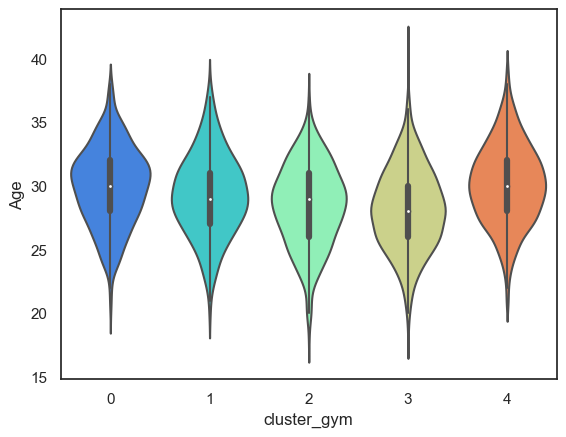

In [71]:
sns.violinplot(x="cluster_gym", y="Age", data=df, palette='rainbow');

    The second and third clusters contain clients under 20 years old.
    In the third cluster, the median age is around 27 years, while in the other clusters it is higher.

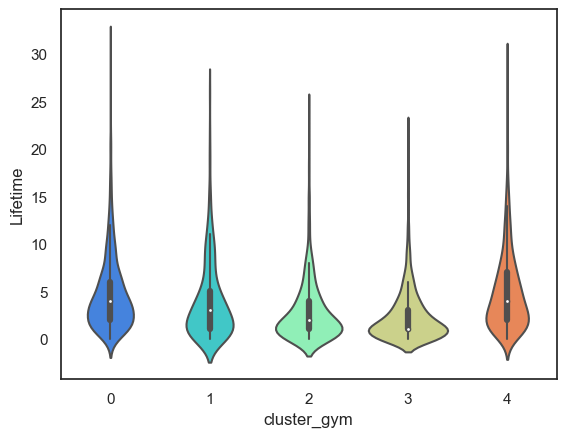

In [72]:
sns.violinplot(x="cluster_gym", y="Lifetime", data=df, palette='rainbow');

    In the second and third clusters, most of the values ​​fall within 1-2 months

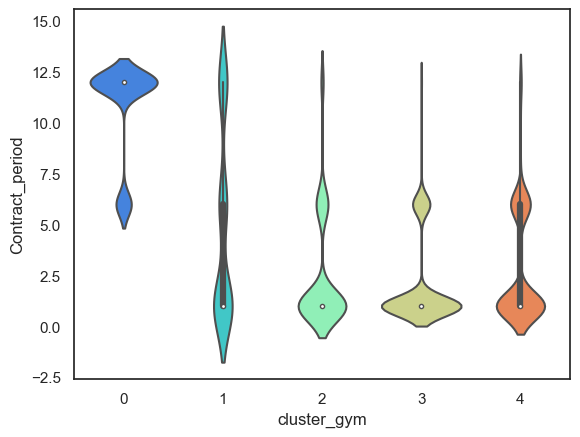

In [73]:
sns.violinplot(x="cluster_gym", y="Contract_period", data=df, palette='rainbow');

    In the second and third clusters, the majority of values ​​are for one-month subscriptions, and a small number are for six-month subscriptions.

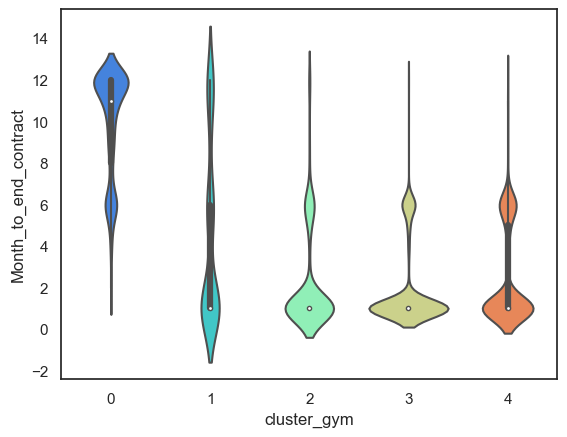

In [74]:
sns.violinplot(x="cluster_gym", y="Month_to_end_contract", data=df, palette='rainbow');

    In the third cluster, most of the values ​​fall within 1 month.

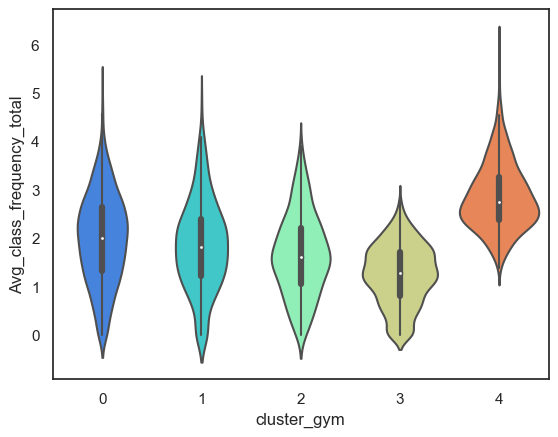

In [75]:
sns.violinplot(x="cluster_gym", y="Avg_class_frequency_total", data=df, palette='rainbow');

    The third cluster spent the least on additional services.

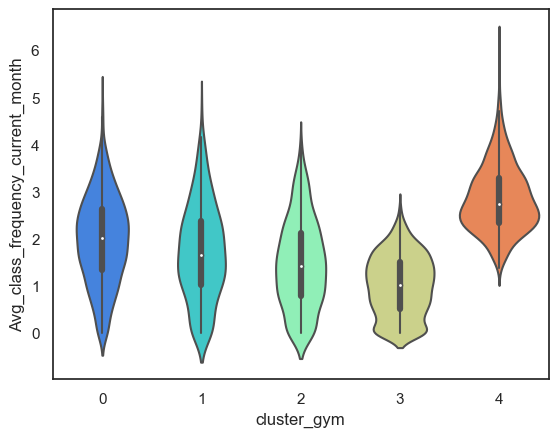

In [76]:
sns.violinplot(x="cluster_gym", y="Avg_class_frequency_current_month", data=df, palette='rainbow');

    The third cluster has the lowest average weekly visit frequency for the previous month.

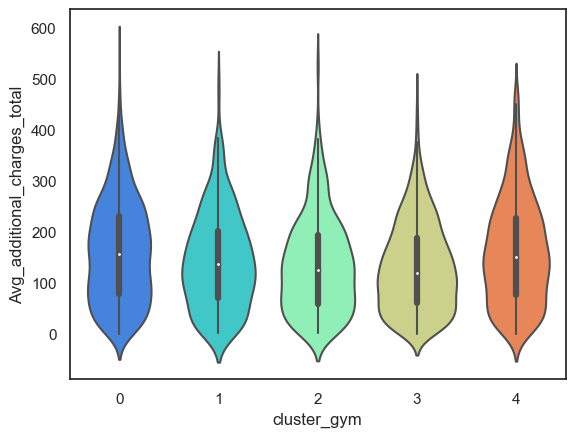

In [77]:
sns.violinplot(x="cluster_gym", y="Avg_additional_charges_total", data=df, palette='rainbow');

    The graph shows no significant differences between clusters in the average weekly visit frequency over the entire period since the subscription began.

###  4.4. Churn Rate for Each Resulting Cluster <a class="anchor" id="4-4-bullet"></a>

In [78]:
proportion_churn = df.groupby(['cluster_gym', 'Churn']).agg({'Churn':'count'})
proportion_churn

Churn
cluster_gym Churn       
0           0        982
            1         28
1           0        282
            1        103
2           0        281
            1        224
3           0        613
            1        649
4           0        781
            1         57

Text(0, 0.5, 'Number')

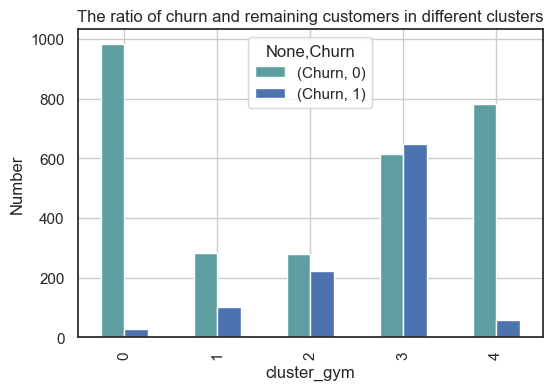

In [79]:
df.pivot_table(index='cluster_gym', columns='Churn', aggfunc=({'Churn':'count'})).plot(kind='bar', grid=True, color = ('cadetblue', 'b'), figsize=(6, 4))
plt.title('The ratio of churn and remaining customers in different clusters')
plt.ylabel('Number')

We see that cluster zero has the best performance:
- 97.23% of customers continued visiting and 2.77% of customers churn.

Cluster four is in second place:
- 93.19% of customers continued visiting and 6.8% of customers churn.

Cluster one is in third place:
- 73.25% of customers continued visiting and 26.75% of customers churn.

Cluster two is in fourth place:
- 55.64% of customers continued visiting and 44.36% of customers churn.

Cluster three is in fifth place:
- 48.57% of customers continued visiting and 51.43% of customers churn.

        
## Step 5. Conclusion<a class="anchor" id="5-bullet"></a>

* Analysis showed that clients with memberships lasting 6-12 months are more likely to stay. These clients have longer Lifetimes. Recommendations: The fitness center should encourage customers to purchase long-term memberships.

* This can be done through discounts on the first membership ("refer a friend," "partner company employee"). These metrics were weighted in the clustering.

* The fitness center should note that clients in the younger age group are more likely to churn. Marketing efforts should be considered to retain clients under 25.

* Clients with an average frequency of once a week churn more often than clients with an average frequency of 2-3 times a week.

* Clusters in which clients attended more group classes have higher churn rates.

* Clients who stopped visiting often had their memberships expired. It's worth paying close attention to clients whose memberships are about to expire. Find out if they're happy with everything, what changes/improvements they'd like to see, offer promotions, or special terms. Ensure the customer will renew their membership.

* The 'Near_Location' feature turned out to be controversial. At first glance, it seems logical that customers prefer clubs in the same area as their home or work. Customers living in a different area are more likely to churn due to inconvenient location. But, for example, the third cluster doesn't include customers who live or work in a different area. This cluster, however, has the highest churn rate. Therefore, in this cluster, the sum of the factors prevails over the 'Near_Location' feature.